# Analyse Exploratoire et Nettoyage - Données Immobilières Madrid

**Objectif :** Préparer le dataset pour la modélisation.
1. **Audit :** Détection des valeurs manquantes et anomalies.
2. **EDA :** Compréhension de la variable cible (Prix) et des corrélations.
3. **Pipeline de Nettoyage :** Traitement des valeurs manquantes, Feature Engineering (Quartiers, Étages) et encodage.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration visuelle
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('../backend/data/houses_madrid.csv')
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head(3)

Dataset chargé : 21742 lignes, 58 colonnes


,Unnamed: 0,id,title,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,latitude,longitude,raw_address,is_exact_address_hidden,street_name,street_number,portal,floor,is_floor_under,door,neighborhood_id,operation,rent_price,rent_price_by_area,is_rent_price_known,buy_price,buy_price_by_area,is_buy_price_known,house_type_id,is_renewal_needed,is_new_development,built_year,has_central_heating,has_individual_heating,are_pets_allowed,has_ac,has_fitted_wardrobes,has_lift,is_exterior,has_garden,has_pool,has_terrace,has_balcony,has_storage_room,is_furnished,is_kitchen_equipped,is_accessible,has_green_zones,energy_certificate,has_parking,has_private_parking,has_public_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,0,21742,"Piso en venta en calle de Godella, 64","San Cristóbal, Madrid",64.0,60.0,2,1.0,NaN,NaN,NaN,NaN,"Calle de Godella, 64",False,Calle de Godella,64,NaN,3,False,NaN,Neighborhood 135: San Cristóbal (1308.89 €/m2)...,sale,471,NaN,False,85000,1328,True,HouseType 1: Pisos,False,False,1960.0,NaN,NaN,NaN,True,NaN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D,False,NaN,NaN,NaN,NaN,False,True,False,False
1,1,21741,Piso en venta en calle de la del Manojo de Rosas,"Los Ángeles, Madrid",70.0,NaN,3,1.0,NaN,NaN,NaN,NaN,Calle de la del Manojo de Rosas,True,Calle de la del Manojo de Rosas,NaN,NaN,4,False,NaN,Neighborhood 132: Los Ángeles (1796.68 €/m2) -...,sale,666,NaN,False,129900,1856,True,HouseType 1: Pisos,True,False,NaN,NaN,NaN,NaN,NaN,True,True,True,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,en trámite,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,21740,"Piso en venta en calle del Talco, 68","San Andrés, Madrid",94.0,54.0,2,2.0,NaN,NaN,NaN,NaN,"Calle del Talco, 68",False,Calle del Talco,68,NaN,1,False,NaN,Neighborhood 134: San Andrés (1617.18 €/m2) - ...,sale,722,NaN,False,144247,1535,True,HouseType 1: Pisos,False,False,NaN,False,True,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,no indicado,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cleaning Data

## 1. Audit des Données
Analyse du taux de remplissage et identification des colonnes inutilisables (>80% de vide ou identifiants).

Top 10 colonnes manquantes (%) :
rent_price_by_area     100.0
is_furnished           100.0
latitude               100.0
longitude              100.0
has_private_parking    100.0
has_public_parking     100.0
portal                 100.0
is_kitchen_equipped    100.0
are_pets_allowed       100.0
door                   100.0
dtype: float64


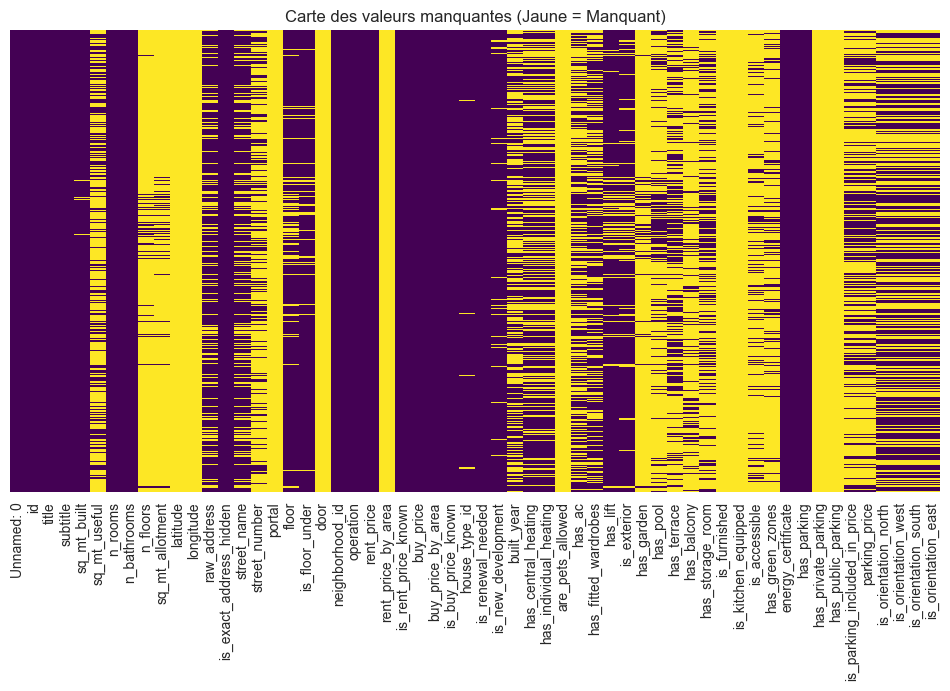

In [7]:
# Calcul des pourcentages de vide
missing_ratio = df.isna().mean() * 100
missing_cols = missing_ratio[missing_ratio > 0].sort_values(ascending=False)

print("Top 10 colonnes manquantes (%) :")
print(missing_cols.head(10))

# Visualisation (Heatmap)
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Carte des valeurs manquantes (Jaune = Manquant)")
plt.show()

## 2. Analyse Exploratoire (EDA)
Focus sur la variable cible `buy_price` et les corrélations initiales avant nettoyage.

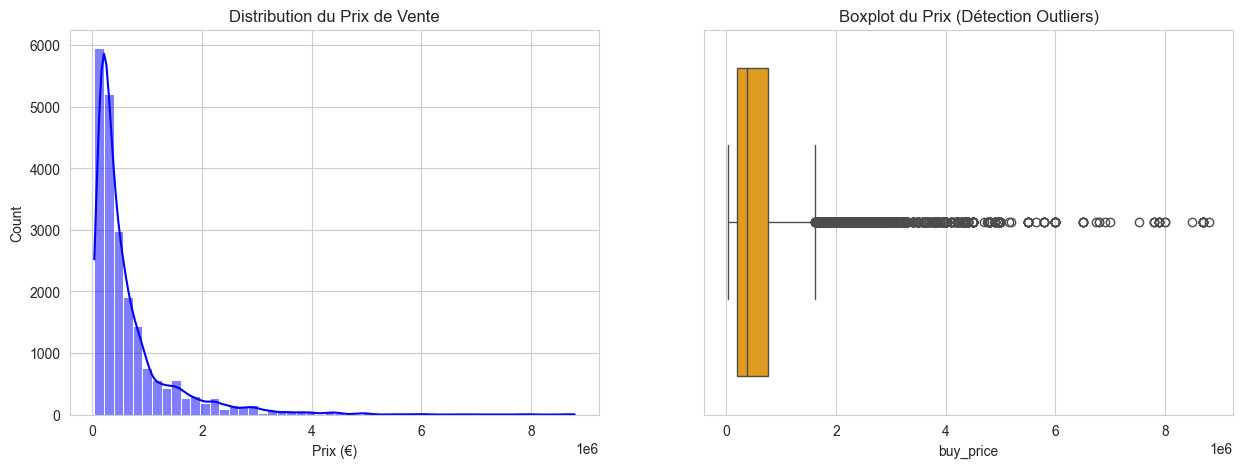

Prix Médian : 375,000 €


In [8]:
# Nettoyage rapide pour visualisation (suppression des prix manquants)
df_viz = df.dropna(subset=['buy_price'])
df_viz = df_viz[df_viz['buy_price'] > 10000] # Filtre anomalies bas prix

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution
sns.histplot(df_viz['buy_price'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution du Prix de Vente')
axes[0].set_xlabel('Prix (€)')

# Boxplot
sns.boxplot(x=df_viz['buy_price'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot du Prix (Détection Outliers)')

plt.show()

print(f"Prix Médian : {df_viz['buy_price'].median():,.0f} €")

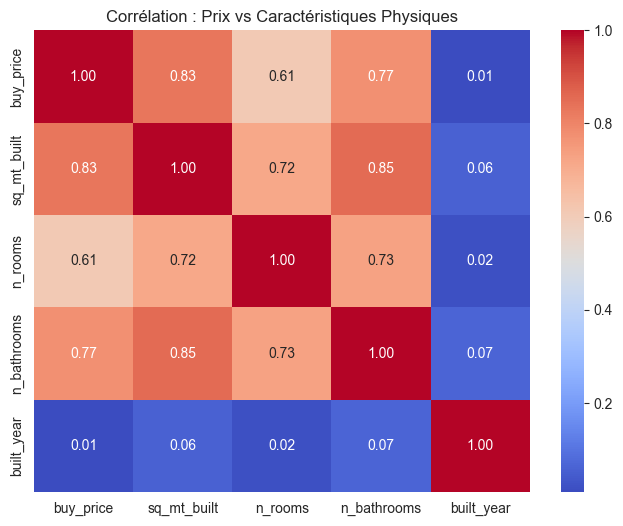

In [9]:
# Sélection des variables numériques clés
cols_corr = ['buy_price', 'sq_mt_built', 'n_rooms', 'n_bathrooms', 'built_year']
corr_matrix = df_viz[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélation : Prix vs Caractéristiques Physiques')
plt.show()

## 3. Pipeline de Nettoyage et Feature Engineering
Application des règles métier définies :
1. **Suppressions :** Colonnes vides (>90%), fuites de données (prix/m²), et identifiants.
2. **Transformations :**
   - Extraction Quartier/District depuis `neighborhood_id`.
   - Nettoyage `floor` (Bajo -> 0, etc.).
   - Consolidation `has_parking`.
3. **Imputations :** Booléens (NaN=False), Numériques (NaN=Médiane).

In [10]:
import pandas as pd
# import numpy as np

# 1. INITIALISATION ET NETTOYAGE RADICAL
df_clean = df.copy()

In [11]:
# --- 0. RESET OBLIGATOIRE (Pour éviter le KeyError si on relance la cellule) ---
# On repart toujours du dataframe original chargé en mémoire
df_clean = df.copy()

# --- 1. NETTOYAGE PRÉLIMINAIRE ---
df_clean.columns = df_clean.columns.str.strip()

# On retire les colonnes parking de la liste de suppression immédiate
cols_to_drop_now = [
    # A. Identifiants & Technique
    'Unnamed: 0', 'id', 'is_exact_address_hidden', 'latitude', 'longitude',
    
    # B. Textes Libres & Adresses (Bruit)
    'title', 'subtitle', 'raw_address', 'street_name', 'street_number', 
    'portal', 'door', 
    
    # C. Fuites de données & Hors Sujet
    'buy_price_by_area', 'is_buy_price_known', # Fuites critiques
    'rent_price', 'rent_price_by_area', 'is_rent_price_known', 
    'operation', # Constante ('sale')
    
    # D. Redondances Techniques
    'n_floors', 'sq_mt_allotment', 'is_floor_under',
    'sq_mt_useful', # On garde sq_mt_built
    
    # E. Colonnes vides ou à faible valeur (Orientations, équipements, etc.)
    'is_orientation_north', 'is_orientation_south', 'is_orientation_west', 'is_orientation_east',
    'is_furnished', 'is_kitchen_equipped', 'are_pets_allowed',
    'has_green_zones', 'is_accessible', 'has_fitted_wardrobes', 
    'has_individual_heating', 'has_central_heating', 'has_balcony',
    'has_public_parking', 'has_private_parking'
]
df_clean.drop(columns=cols_to_drop_now, errors='ignore', inplace=True)

# --- 2. FILTRAGE DES OUTLIERS ---

# Calcul temporaire
df_clean['price_per_sq_mt'] = df_clean['buy_price'] / df_clean['sq_mt_built']

# A. Définition des bornes (Surface)
mask_surface = df_clean['sq_mt_built'].between(15, 500)

# B. Définition des bornes (Prix/m²)
Q1 = df_clean['price_per_sq_mt'].quantile(0.25)
Q3 = df_clean['price_per_sq_mt'].quantile(0.75)
IQR = Q3 - Q1
mask_price = df_clean['price_per_sq_mt'].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

df_clean = df_clean[mask_surface & mask_price].copy()
df_clean.drop(columns=['price_per_sq_mt'], inplace=True)

print(f"Dimensions après filtrage : {df_clean.shape}")

# --- 3. FEATURE ENGINEERING ---

# A. Extraction Neighborhood (Sécurisée)
if 'neighborhood_id' in df_clean.columns:
    pattern = r"Neighborhood \d+: (?P<neighborhood>.*?) \((?P<neigh_price_m2>\d+\.?\d*) €/m2\) - District \d+: (?P<district>.*)"
    extracted = df_clean['neighborhood_id'].str.extract(pattern)
    df_clean['neighborhood'] = extracted['neighborhood'].str.strip()
    df_clean['district'] = extracted['district'].str.strip()
    df_clean['neigh_price_m2'] = pd.to_numeric(extracted['neigh_price_m2'])
    df_clean.drop(columns=['neighborhood_id'], inplace=True)
else:
    print("Alerte : 'neighborhood_id' déjà traitée ou absente.")


# normalisation des champs de texte
target_cols = ['title','subtitle','street_name','neighborhood', 'district', 'house_type', 'energy_certificate','house_type','raw_address']
for col in target_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.lower().replace('nan', np.nan)

print(f"Normalisation terminée pour : {target_cols}")

# fusion avec les colonnes de parking 
if 'is_parking_included_in_price' in df_clean.columns:
    df_clean['has_parking'] = df_clean['is_parking_included_in_price'].fillna(False).infer_objects(copy=False).astype(int)
    df_clean.drop(columns=['is_parking_included_in_price', 'parking_price'], errors='ignore', inplace=True)
else:
    df_clean['has_parking'] = 0

# nettoyage de floor
def clean_floor(val):
    if pd.isna(val): return np.nan
    val = str(val).lower()
    if 'bajo' in val: return 0
    if 'sótano' in val: return -1
    if 'entreplanta' in val: return 0.5
    try: return float(val)
    except: return np.nan

df_clean['floor'] = df_clean['floor'].apply(clean_floor)

# encodage
energy_map = {'a': 7, 'b': 6, 'c': 5, 'd': 4, 'e': 3, 'f': 2, 'g': 1}
df_clean['energy_certificate'] = df_clean['energy_certificate'].map(energy_map)

if 'house_type_id' in df_clean.columns:
    df_clean['house_type'] = df_clean['house_type_id'].str.split(':', expand=True)[1].str.strip()
    df_clean.drop(columns=['house_type_id'], inplace=True)

#imputation
#Booleen
bool_cols = [c for c in df_clean.columns if c.startswith(('has_', 'is_'))]
df_clean[bool_cols] = df_clean[bool_cols].fillna(0).astype(int)

# numerique
num_cols = ['built_year', 'sq_mt_built', 'n_rooms', 'n_bathrooms', 'neigh_price_m2', 'floor', 'energy_certificate']
for col in num_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# categorielle
cat_cols = ['neighborhood', 'district', 'house_type']
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Dimension : {df_clean.shape}")
df_clean.head()

Dimensions après filtrage : (20418, 21)
Normalisation terminée pour : ['title', 'subtitle', 'street_name', 'neighborhood', 'district', 'house_type', 'energy_certificate', 'house_type', 'raw_address']
Dimension : (20418, 21)


/var/folders/kd/vq32c04j73n3rh4gd0fkj9540000gn/T/ipykernel_52592/3039438193.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['has_parking'] = df_clean['is_parking_included_in_price'].fillna(False).infer_objects(copy=False).astype(int)


,sq_mt_built,n_rooms,n_bathrooms,floor,buy_price,is_renewal_needed,is_new_development,built_year,has_ac,has_lift,is_exterior,has_garden,has_pool,has_terrace,has_storage_room,energy_certificate,has_parking,neighborhood,district,neigh_price_m2,house_type
0,64.0,2,1.0,3.0,85000,0,0,1960.0,1,0,1,0,0,0,0,4.0,0,san cristóbal,villaverde,1308.89,Pisos
1,70.0,3,1.0,4.0,129900,1,0,1970.0,0,1,1,0,0,1,0,3.0,0,los ángeles,villaverde,1796.68,Pisos
2,94.0,2,2.0,1.0,144247,0,0,1970.0,0,1,1,0,0,0,1,3.0,0,san andrés,villaverde,1617.18,Pisos
3,64.0,2,1.0,0.0,109900,0,0,1955.0,0,1,1,0,0,0,1,3.0,0,san andrés,villaverde,1617.18,Pisos
4,108.0,2,2.0,4.0,260000,0,0,2003.0,1,1,1,0,1,0,1,3.0,1,los rosales,villaverde,1827.79,Pisos


## 4. Vérification et Export
Vérification de la qualité du dataset final (plus de NaN) et sauvegarde.

In [12]:
# Vérification qu'il ne reste plus de vide
print("Valeurs manquantes restantes :", df_clean.isna().sum().sum())

# Aperçu des colonnes finales
print("\nColonnes conservées :")
print(df_clean.columns.tolist())
print(f"Dimensions : {df_clean.shape}")
print("-" * 30)
df_clean.info()
# Aperçu des données
df_clean.head()

Valeurs manquantes restantes : 0

Colonnes conservées :
['sq_mt_built', 'n_rooms', 'n_bathrooms', 'floor', 'buy_price', 'is_renewal_needed', 'is_new_development', 'built_year', 'has_ac', 'has_lift', 'is_exterior', 'has_garden', 'has_pool', 'has_terrace', 'has_storage_room', 'energy_certificate', 'has_parking', 'neighborhood', 'district', 'neigh_price_m2', 'house_type']
Dimensions : (20418, 21)
------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 20418 entries, 0 to 21741
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sq_mt_built         20418 non-null  float64
 1   n_rooms             20418 non-null  int64  
 2   n_bathrooms         20418 non-null  float64
 3   floor               20418 non-null  float64
 4   buy_price           20418 non-null  int64  
 5   is_renewal_needed   20418 non-null  int64  
 6   is_new_development  20418 non-null  int64  
 7   built_year          20

,sq_mt_built,n_rooms,n_bathrooms,floor,buy_price,is_renewal_needed,is_new_development,built_year,has_ac,has_lift,is_exterior,has_garden,has_pool,has_terrace,has_storage_room,energy_certificate,has_parking,neighborhood,district,neigh_price_m2,house_type
0,64.0,2,1.0,3.0,85000,0,0,1960.0,1,0,1,0,0,0,0,4.0,0,san cristóbal,villaverde,1308.89,Pisos
1,70.0,3,1.0,4.0,129900,1,0,1970.0,0,1,1,0,0,1,0,3.0,0,los ángeles,villaverde,1796.68,Pisos
2,94.0,2,2.0,1.0,144247,0,0,1970.0,0,1,1,0,0,0,1,3.0,0,san andrés,villaverde,1617.18,Pisos
3,64.0,2,1.0,0.0,109900,0,0,1955.0,0,1,1,0,0,0,1,3.0,0,san andrés,villaverde,1617.18,Pisos
4,108.0,2,2.0,4.0,260000,0,0,2003.0,1,1,1,0,1,0,1,3.0,1,los rosales,villaverde,1827.79,Pisos


In [14]:
# Sauvegarde du fichier MASTER prêt pour le Machine Learning
df_clean.to_csv('../backend/data/houses_madrid_final_preprocessed.csv', index=False)